<a href="https://colab.research.google.com/github/agarwalpratik/aiml/blob/main/Automating_Port_Operations_DeepLearning_Part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2.	Build a lightweight model with the aim of deploying the solution on a mobile device using transfer learning. You can use any lightweight pre-trained model as the initial (first) layer. MobileNetV2 is a popular lightweight pre-trained model built using Keras API.

2.1.	Split the dataset into train and test datasets in the ration 70:30, with shuffle and random state=1.

2.2.	Use tf.keras.preprocessing.image_dataset_from_directory to load the train and test datasets. This function also supports data normalization.
(Hint: Image_scale=1./255).

2.3.	Load train, validation and test datasets in batches of 32 using the function initialized in the above step.

2.4.	Build a CNN network using Keras with the following layers.

•	Load MobileNetV2 - Light Model as the first layer
(Hint: Keras API Doc)

•	GLobalAveragePooling2D layer

•	Dropout(0.2)

•	Dense layer with 256 neurons and activation relu

•	BatchNormalization layer

•	Dropout(0.1)

•	Dense layer with 128 neurons and activation relu

•	BatchNormalization layer

•	Dropout(0.1)

•	Dense layer with 9 neurons and activation softmax

2.5.	Compile the model with Adam optimizer, categorical_crossentropy loss, and metrics accuracy, Precision, and Recall.

2.6.	Train the model for 50 epochs and Early stopping while monitoring validation loss.

2.7.	Evaluate the model on test images and print the test loss and accuracy.

2.8.	Plot Train loss Vs Validation loss and Train accuracy Vs Validation accuracy.


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import os

tf.__version__

'2.17.1'

In [2]:
#Extract the Zip File

!unzip boat_type_classification_dataset.zip


Archive:  boat_type_classification_dataset.zip
   creating: boat_type_classification_dataset/
   creating: boat_type_classification_dataset/buoy/
  inflating: boat_type_classification_dataset/buoy/1.jpg  
  inflating: boat_type_classification_dataset/buoy/10.jpg  
  inflating: boat_type_classification_dataset/buoy/11.jpg  
  inflating: boat_type_classification_dataset/buoy/12.jpg  
  inflating: boat_type_classification_dataset/buoy/13.jpg  
  inflating: boat_type_classification_dataset/buoy/14.jpg  
  inflating: boat_type_classification_dataset/buoy/15.jpg  
  inflating: boat_type_classification_dataset/buoy/16.jpg  
  inflating: boat_type_classification_dataset/buoy/17.jpg  
  inflating: boat_type_classification_dataset/buoy/18.jpg  
  inflating: boat_type_classification_dataset/buoy/19.jpg  
  inflating: boat_type_classification_dataset/buoy/2.jpg  
  inflating: boat_type_classification_dataset/buoy/20.jpg  
  inflating: boat_type_classification_dataset/buoy/21.jpg  
  inflating: boa

In [3]:
#2.1.	Split the dataset into train and test datasets in the ration 70:30, with shuffle and random state=1.
#2.2.	Use tf.keras.preprocessing.image_dataset_from_directory to load the train and test datasets. This function also supports data normalization.
#(Hint: Image_scale=1./255).
#2.3.	Load train, validation and test datasets in batches of 32 using the function initialized in the above step.

my_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255.0,
                                                               validation_split=0.3)

trainImageData = my_generator.flow_from_directory('boat_type_classification_dataset',
                                                     batch_size=32,
                                                     class_mode='categorical',
                                                     seed=1,
                                                     target_size=(128,128),
                                                     subset='training')

testImageData = my_generator.flow_from_directory('boat_type_classification_dataset',
                                                     batch_size=32,
                                                     class_mode='categorical',
                                                     seed=1,
                                                     target_size=(128,128),
                                                     subset='validation')


Found 820 images belonging to 9 classes.
Found 342 images belonging to 9 classes.


2.4.	Build a CNN network using Keras with the following layers.

•	Load MobileNetV2 - Light Model as the first layer
(Hint: Keras API Doc)

•	GLobalAveragePooling2D layer

•	Dropout(0.2)

•	Dense layer with 256 neurons and activation relu

•	BatchNormalization layer

•	Dropout(0.1)

•	Dense layer with 128 neurons and activation relu

•	BatchNormalization layer

•	Dropout(0.1)

•	Dense layer with 9 neurons and activation softmax


In [5]:
base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = tf.keras.Sequential()

model.add(base_model)

model.add(tf.keras.layers.GlobalAveragePooling2D())

model.add(tf.keras.layers.Dropout(0.2))

model.add(tf.keras.layers.Dense(units=256, activation='relu'))

model.add(tf.keras.layers.BatchNormalization())

model.add(tf.keras.layers.Dropout(0.1))

model.add(tf.keras.layers.Dense(units=128, activation='relu'))

model.add(tf.keras.layers.BatchNormalization())

model.add(tf.keras.layers.Dropout(0.1))

model.add(tf.keras.layers.Dense(units=9, activation='softmax'))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 9)                   │           1,161 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,621,513 (10.00 MB)

 Trainable params: 362,761 (1.38 MB)

 Non-trainable params: 2,258,752 (8.62 MB)

In [7]:
#2.5.	Compile the model with Adam optimizer, categorical_crossentropy loss, and metrics accuracy, Precision, and Recall.

model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

In [10]:
#2.6.	Train the model for 50 epochs and Early stopping while monitoring validation loss.

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    trainImageData,
    validation_data=testImageData,
    epochs=50,
    callbacks=[early_stopping]
)

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


26/26 ━━━━━━━━━━━━━━━━━━━━ 40s 928ms/step - accuracy: 0.3795 - loss: 1.9376 - precision: 0.5591 - recall: 0.2851 - val_accuracy: 0.7953 - val_loss: 0.7007 - val_precision: 0.9157 - val_recall: 0.6667
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 300ms/step - accuracy: 0.8523 - loss: 0.4764 - precision: 0.9042 - recall: 0.7798 - val_accuracy: 0.8246 - val_loss: 0.5938 - val_precision: 0.9039 - val_recall: 0.7427
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 257ms/step - accuracy: 0.9289 - loss: 0.2594 - precision: 0.9572 - recall: 0.8722 - val_accuracy: 0.8450 - val_loss: 0.5757 - val_precision: 0.9085 - val_recall: 0.7544
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 10s 249ms/step - accuracy: 0.9368 - loss: 0.1968 - precision: 0.9667 - recall: 0.9053 - val_accuracy: 0.8333 - val_loss: 0.5336 - val_precision: 0.8914 - val_recall: 0.7924
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 9s 304ms/step - accuracy: 0.9604 - loss: 0.1497 - precision: 0.9759 - recall: 0.9411 - val_accuracy: 0.8333 - val_loss: 0.5581 - va

In [11]:
#Deploy Example
model

<Sequential name=sequential, built=True>

In [12]:
img = tf.keras.preprocessing.image.load_img('boat_type_classification_dataset/kayak/10.jpg', target_size=(128,128))

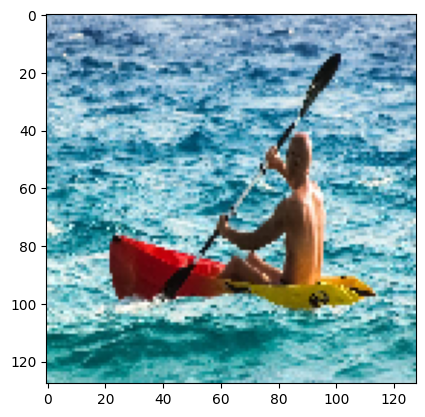

In [13]:
import matplotlib.pyplot as plt
plt.imshow(img)

In [14]:
imgArray= tf.keras.preprocessing.image.img_to_array(img)
compatibleArray = np.expand_dims(imgArray, axis=0)

In [15]:
{v:k for k,v in trainImageData.class_indices.items()} [ np.argmax(model.predict(compatibleArray)) ]

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


'sailboat'

In [19]:
#2.7.	Evaluate the model on test images and print the test loss and accuracy.

test_loss, test_accuracy, test_precision, test_recall = model.evaluate(testImageData)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}, Test Recall: {test_recall:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 204ms/step - accuracy: 0.8109 - loss: 0.6179 - precision: 0.8586 - recall: 0.7703
Test Loss: 0.5336, Test Accuracy: 0.8333
Test Precision: 0.8914, Test Recall: 0.7924


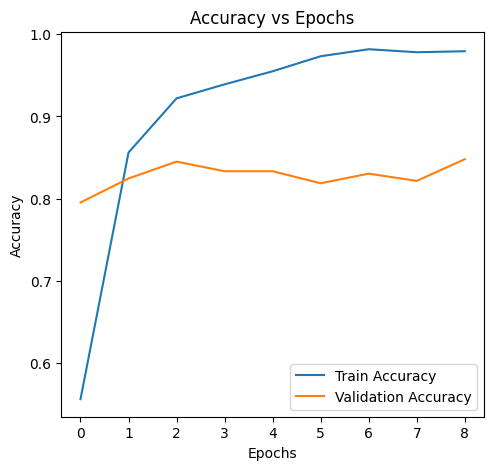

In [20]:
#2.8.	Plot Train loss Vs Validation loss and Train accuracy Vs Validation accuracy.

plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy vs Epochs')

plt.show()

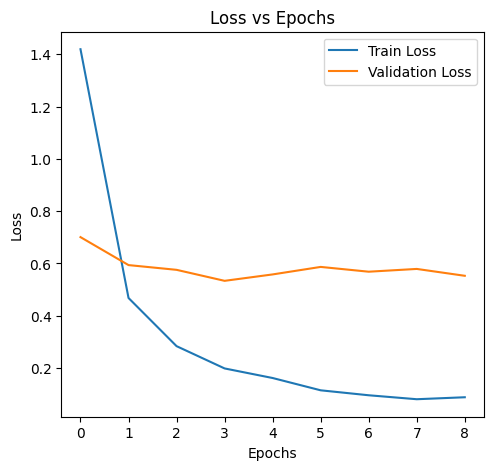

In [17]:
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss vs Epochs')

plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 465ms/step


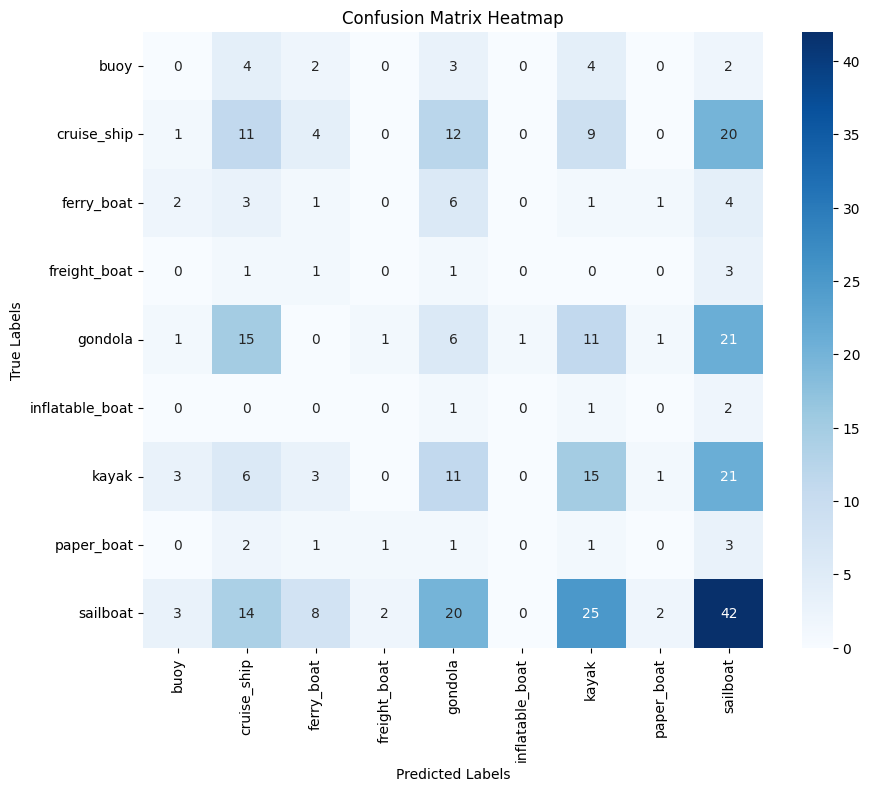

Classification Report:

                 precision    recall  f1-score   support

           buoy       0.00      0.00      0.00        15
    cruise_ship       0.20      0.19      0.19        57
     ferry_boat       0.05      0.06      0.05        18
   freight_boat       0.00      0.00      0.00         6
        gondola       0.10      0.11      0.10        57
inflatable_boat       0.00      0.00      0.00         4
          kayak       0.22      0.25      0.24        60
     paper_boat       0.00      0.00      0.00         9
       sailboat       0.36      0.36      0.36       116

       accuracy                           0.22       342
      macro avg       0.10      0.11      0.10       342
   weighted avg       0.21      0.22      0.22       342



In [21]:
# Plot heatmap of the confusion matrix and print classification report.

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Number of samples in the test dataset
test_steps = testImageData.samples // testImageData.batch_size
if testImageData.samples % testImageData.batch_size != 0:
    test_steps += 1  # Include the last incomplete batch if it exists

# Generate predictions
y_pred_prob = model.predict(testImageData, steps=test_steps, verbose=1)

# Align the predicted and true labels
y_pred = np.argmax(y_pred_prob, axis=1)  # Predicted class indices
y_true = testImageData.classes[:len(y_pred)]  # True labels aligned with predictions

# Get class labels (mapping of indices to class names)
class_labels = list(testImageData.class_indices.keys())

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))


#3.	Compare the results of both models built in steps 1 and 2 and state your observations.


Comparison and Observations

Based on the classification reports for both the MobileNetV2 model and the CNN model, here are the key observations and comparisons:



Performance Metrics

Overall Accuracy:

MobileNetV2: 22%

CNN: 29%

The CNN model slightly outperforms MobileNetV2 in overall accuracy, likely because it is trained specifically on this dataset without relying on potentially mismatched pre-trained features.


Precision, Recall, and F1-Score:

Both models have low precision and recall for most classes, indicating challenges in correctly identifying certain boat types.
The CNN model achieves higher recall for gondola and sailboat, the two relatively larger classes.
MobileNetV2 achieves a slightly more balanced performance across classes but still struggles with minority classes (e.g., freight_boat, paper_boat).


Class-wise Performance:

CNN performs better for sailboat (36% precision, 68% recall), which is the largest class, indicating a bias towards the dominant class.
MobileNetV2 shows a better balance across classes but does not excel in any particular category.
Training Dynamics


Overfitting:

The CNN model might have overfit to the training data, as indicated by its higher performance on majority classes but poor generalization on minority classes.
MobileNetV2, while leveraging pre-trained weights, may not have learned dataset-specific nuances, especially due to the small dataset size.


Convergence:

MobileNetV2 likely converged faster due to transfer learning, but its accuracy plateaued early, showing difficulty in adapting to this specific dataset.
Dataset Challenges


Class Imbalance:

Both models struggle with the minority classes (freight_boat, paper_boat, inflatable_boat) due to insufficient data.
sailboat and kayak are better recognized because they have more samples in the dataset.


Small Dataset Size:

With only 1162 images across 9 classes, the dataset is too small for training a deep model from scratch (CNN) or fine-tuning (MobileNetV2).
Data augmentation and synthetic data generation could help improve performance.


Visual Similarity:

The boats may look similar, leading to poor discrimination between classes.
Deployment Suitability


MobileNetV2:

Despite lower accuracy, MobileNetV2 is lightweight and designed for deployment on mobile devices, making it a more practical choice for on-device applications.


CNN:

The CNN model's performance is slightly better but comes at the cost of higher computational requirements, making it less ideal for mobile deployment.
Suggestions for Improvement
